
# mercados + series de tiempo + research,
## semana 03 
> pregunta fundamental para cualquier alpha: ¿la información disponible hoy realmente ayuda a predecir mañana?

Conditional expectation como definición de señal. Supón que un activo tiene $ E[r_{t+1}]=0 $ , pero observas una variable $ X_t\in\{-1,+1\} $. De 1,000 observaciones obtienes:

$$ E[r_{t+1}\mid X_t=+1]=+6\text{ bps}, \qquad E[r_{t+1}\mid X_t=-1]=-4\text{ bps}. $$

Además,

$$ P(X_t=+1)=0.40,\qquad P(X_t=-1)=0.60. $$

Calcula mediante la ley de esperanza total:

$$ E[r_{t+1}] = \sum_x E[r_{t+1}\mid X_t=x]P(X_t=x). $$

Después responde: ¿es posible que $ E[r_{t+1}] $  sea aproximadamente cero y aun así $ (X_t $  contenga información predictiva? Explica qué diferencia conceptual existe entre

$$ E[r_{t+1}] \quad\text{y}\quad E[r_{t+1}\mid\mathcal F_t]. $$

Ésta es la conexión matemática:  <b> un alpha no intenta necesariamente demostrar que los retornos tienen media distinta de cero; intenta encontrar información disponible en $ t $ que cambie la distribución condicional de $ r_{t+1} $ </b>

,observaciones,retorno_condicional,volatilidad,P(x_t),contribucion
x_t,,,,,
-1,6048,-0.03%,1.00%,60.48%,-0.0165%
1,3952,0.08%,1.01%,39.52%,0.0300%


Media directa de r_(t+1): 0.0136%
Media por esperanza total: 0.0136%
Media teórica: -0.0000%
Media condicional si x_t =  1: 0.06% = +6 bps
Media condicional si x_t = -1: -0.04% = -4 bps


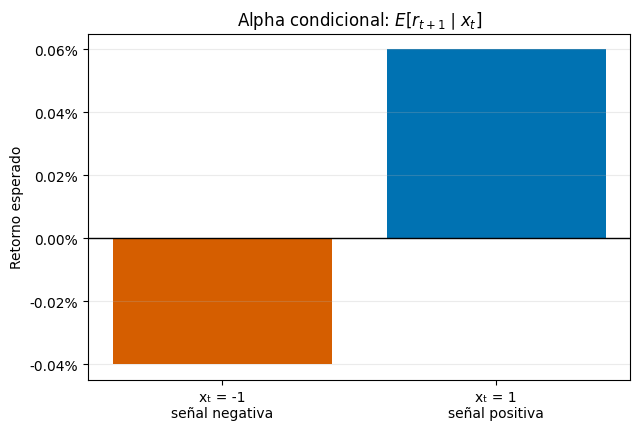

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
n = 10_000

# 1 bp = 0.0001
mu_up = 0.0006     # +6 bps
mu_down = -0.0004  # -4 bps

# Señal observada hoy:
# x_t = 1  -> señal positiva
# x_t = -1 -> señal negativa
x_t = rng.choice(
    [-1, 1],
    size=n,
    p=[0.60, 0.40]
)

# Retorno futuro:
# la media depende de x_t, pero hay ruido no predecible
ruido = rng.normal(loc=0, scale=0.01, size=n)

r_t_plus_1 = np.where(
    x_t == 1,
    mu_up + ruido,
    mu_down + ruido
)

df = pd.DataFrame({
    "x_t": x_t,
    "r_t_plus_1": r_t_plus_1
})

# Retornos condicionales estimados con la simulación
resumen = (
    df.groupby("x_t")["r_t_plus_1"]
    .agg(
        observaciones="count",
        retorno_condicional="mean",
        volatilidad="std"
    )
)

resumen["P(x_t)"] = resumen["observaciones"] / len(df)
resumen["contribucion"] = (
    resumen["P(x_t)"] * resumen["retorno_condicional"]
)

media_total_esperanza = resumen["contribucion"].sum()
media_total_directa = df["r_t_plus_1"].mean()

display(
    resumen.style.format({
        "retorno_condicional": "{:.2%}",
        "volatilidad": "{:.2%}",
        "P(x_t)": "{:.2%}",
        "contribucion": "{:.4%}",
    })
)

print(f"Media directa de r_(t+1): {media_total_directa:.4%}")
print(f"Media por esperanza total: {media_total_esperanza:.4%}")

# Cálculo teórico exacto, sin ruido
media_teorica = 0.40 * mu_up + 0.60 * mu_down

print(f"Media teórica: {media_teorica:.4%}")
print(f"Media condicional si x_t =  1: {mu_up:.2%} = +6 bps")
print(f"Media condicional si x_t = -1: {mu_down:.2%} = -4 bps")

# Visualización
fig, ax = plt.subplots(figsize=(7, 4.5))

valores_teoricos = [mu_down, mu_up]

ax.bar(
    ["xₜ = -1\nseñal negativa", "xₜ = 1\nseñal positiva"],
    valores_teoricos,
    color=["#D55E00", "#0072B2"]
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title(r"Alpha condicional: $E[r_{t+1}\mid x_t]$")
ax.set_ylabel("Retorno esperado")
ax.yaxis.set_major_formatter(lambda valor, _: f"{valor:.2%}")
ax.grid(axis="y", alpha=0.25)

plt.show()

<b> Predictibilidad falsa por look-ahead. </b> 

Simula 5_000 retornos i.i.d. 

Construye dos señales:

`signal_valid[t] = sign(r[t-1])`

`signal_bad[t]   = sign(r[t+1])`

y una estrategia sencilla:

$$ PnL_{t+1}=signal_t\,r_{t+1}. $$

Calcula para ambas únicamente mean pnl, std pnl, annualized Sharpe y % profitable days.

Después dibuja explícitamente la línea temporal:

$$ r_{t-1}
\rightarrow
\boxed{\mathcal F_t}
\rightarrow
\text{signal\_valid}_t
\rightarrow
\text{position}_t
\rightarrow
r_{t+1} $$

Tu explicación final debe contestar:

¿por qué signal_bad puede producir un Sharpe espectacular incluso cuando los retornos fueron generados como ruido puro? No arregles el modelo; encuentra exactamente qué información ilegal utilizaste.

- <b> R: </b> só ilegalmente el retorno futuro para decidir la posición de hoy.

In [1]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats 

# simular 5_000 retornos 
rng = np.random.default_rng(seed = 45)
serie = rng.normal(size = 5_000, scale = 0.01)
# señales 
signal_valid = []
signal_bad = []
retornos_futuros = []

for t in range(1, len(serie)-1): 
    signal_valid.append(np.sign(serie[t-1]))
    signal_bad.append(np.sign(serie[t + 1]))
    retornos_futuros.append(serie[t + 1])

signal_valid = np.array(signal_valid)
signal_bad = np.array(signal_bad)
retornos_futuros = np.array(retornos_futuros)

# PnL_{t+1} = signal_t * r_{t+1}
pnl_valid = signal_valid * retornos_futuros
pnl_bad = signal_bad * retornos_futuros


def metricas_pnl(pnl): 
    return {'mean_pnl': pnl.mean(), 
            'std_pnl': pnl.std(ddof= 1), 
            'sharpe_anualizado': pnl.mean()/pnl.std(ddof= 1) * np.sqrt(252), 
            'profitable_days': (pnl > 0).mean(), }

resultado_valid = metricas_pnl(pnl_valid)
resultado_bad = metricas_pnl(pnl_bad)

df_resultados = pd.DataFrame(
    [resultado_valid, resultado_bad],
    index=["signal_valid", "signal_bad"]
)

df_resultados.style.format({
    "mean_pnl": "{:.4%}",
    "std_pnl": "{:.2%}",
    "annualized_sharpe": "{:.2f}",
    "profitable_days": "{:.2%}",
})


,mean_pnl,std_pnl,sharpe_anualizado,profitable_days
signal_valid,0.0248%,1.01%,0.389653,50.62%
signal_bad,0.8024%,0.61%,20.756304,100.00%


<b> Research + Quant Desk | Construye un Information Set Contract.</b>

Este sí quiero que termine como pieza conceptual de tu desk. Imagina que quieres producir a las 10:00:00 una señal para el retorno 10:00–10:05.

Definimos tabla. 

| Variable              | observation_time | available_time | ¿usable a 10:00? |
| --------------------- | ---------------- | -------------- | ---------------- |
| Last trade            | 09:59:59         | 09:59:59       | ?                |
| 5-min bar 09:55–10:00 | 10:00:00         | 10:00:01       | ?                |
| Fundamental report    | 09:30:00         | 09:32:00       | ?                |
| 10:00–10:05 volume    | 10:05:00         | 10:05:00       | ?                |
| Previous close        | día anterior     | día anterior   | ?                |


Decide cada caso utilizando available_time, no simplemente el timestamp que representa el dato.

<b> Respuesta </b>
1. Es usable 
2. No es usable (Look-ahead bias)
3. Usable 
4. No es usable (Look-ahead bias)
5. Es usable

Después escribe una sola regla que debería cumplir cualquier feature antes de entrar a Alpha:

$$ \boxed{\texttt{available\_time(feature)}\leq \texttt{decision\_time}} $$

MI REGLA :  Una feature solo puede entrar al modelo si su available_time es anterior o igual al instante de decisión.

Finalmente explica por qué observation_time y available_time no son necesariamente iguales.

<b> R:</b> observation_time indica cuándo ocurrió o se registró el evento; available_time indica cuándo el sistema realmente pudo conocer y utilizar ese dato. Pueden diferir por retrasos de publicación, procesamiento, agregación, revisión o entrega del proveedor. Por ejemplo, una barra 09:55–10:00 termina a las 10:00, pero si está disponible a las 10:00:01, no puede usarse para decidir exactamente a las 10:00.

# Martes
> si una feature es temporalmente válida, todavía debemos preguntar qué significa que tenga exposición a un factor

<b> Estadística | Una estrategia rentable que en realidad sólo compra beta. </b>

Simula 1000 días:

> `market = np.random.normal(0.0003, 0.01, 1000)`
>
> `eps    = np.random.normal(0, 0.004, 1000)`
> 
> `strategy = 1.5 * market + eps`

Primero calcula el Sharpe de `strategy`.

Después estima mediante OLS:

$$ r_t^{strategy} = \alpha+\beta r_t^{market}+\varepsilon_t. $$

Obtén solamente:

- strategy Sharpe
- estimated alpha
- estimated beta
- residual Sharpe
- R²

Ahora crea:

neutralized = strategy - beta_hat * market

y compara su comportamiento con la estrategia original.

No intentes mejorarla.

La pregunta es:

Si la estrategia tenía un Sharpe atractivo antes de neutralizarla y casi ninguno después, ¿qué descubriste realmente sobre tu “alpha”?
- <b>R: </b> Como $ \hat\beta \approx 1.5 $ , al neutralizar eliminas casi toda la exposición al mercado. En la simulación no construiste un alfa:
$ \alpha = 0 $ : La estrategia sólo tiene beta positiva: sube cuando el mercado sube y baja cuando el mercado baja, amplificada aproximadamente 1.5 veces.

Piensa también qué significa \(R^2\) aquí: no como métrica de forecasting, sino como fracción de la variación explicada por la exposición común.

- <b> R:  </b>tu estrategia se comporta casi como una posición apalancada de mercado con beta \(1.5\), más un componente pequeño de ruido.

In [11]:
import numpy as np 
import scipy.stats as stats 
import statsmodels.api as sm 
rng = np.random.default_rng(seed=  42)
mercado = rng.normal(loc = 0.0003, size = 10_000, scale = 0.01)
shocks    = rng.normal(loc = 0, scale = 0.004, size = 10_000)
strategy = 1.5 * mercado + shocks
# Primero calcula el Sharpe de `strategy`.
sharpe = strategy.mean() / strategy.std(ddof=1)
#Después estima mediante OLS:
# r_t^{strategy} = \alpha+\beta r_t^{market}+\varepsilon_t.
x = sm.add_constant(mercado)
# modelo 
modelo = sm.OLS(strategy, x).fit()
alpha_hat = modelo.params[0]
beta_hat = modelo.params[1]
# reiduo puramente no explicado por el mercado 
residuos = modelo.resid 
residual_sharpe = residuos.mean() / residuos.std(ddof= 1)
print(f'Alfa estimado:{alpha_hat }')
print(f'Beta estimado:{beta_hat}')
print(f'Ratio sharpe:{sharpe}')
print(f'Residuales del sharpe: {residual_sharpe}')
print('R^2:', modelo.rsquared)
######################
# neutralidad
print('\n')
neutralized = strategy - beta_hat * mercado
neutralized_sharpe = neutralized.mean() / neutralized.std(ddof=1)
print(f'Neutralidad Ratio sharpe:{neutralized_sharpe}')

# Después de ajustar OLS
modelo = sm.OLS(strategy, sm.add_constant(mercado)).fit()

# Retornos explicados por alpha + beta * mercado
ajustados = modelo.fittedvalues

# Retornos no explicados por el modelo
residuos = modelo.resid

Alfa estimado:8.23893612785416e-05
Beta estimado:1.4950259585533536
Ratio sharpe:0.024254626822904832
Residuales del sharpe: -6.365571369438768e-17
R^2: 0.9336270366453366


Neutralidad Ratio sharpe:0.020538582267135445


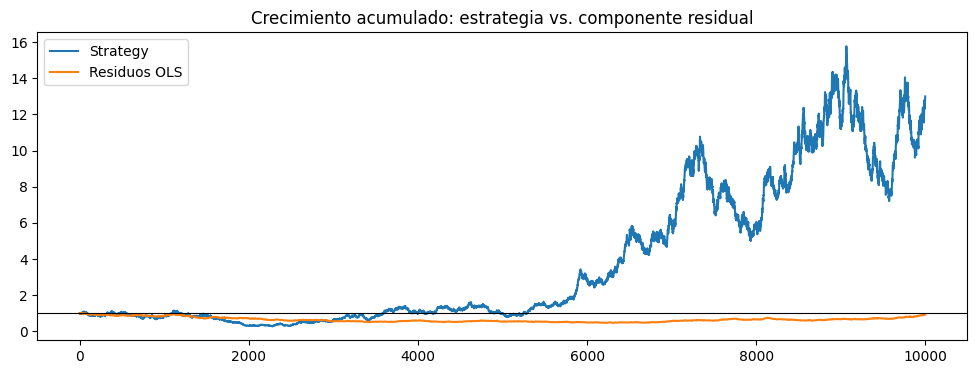

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(np.cumprod(1 + strategy), label="Strategy")
plt.plot(np.cumprod(1 + residuos), label="Residuos OLS")
plt.axhline(1, color="black", linewidth=0.8)
plt.legend()
plt.title("Crecimiento acumulado: estrategia vs. componente residual")
plt.show()

<b> Portfolio + Quant Desk | Una posición pequeña puede crear una exposición grande. </b>

Tu portfolio contiene tres activos:

$$ w= \begin{pmatrix} 0.40\\ 0.35\\ 0.25 \end{pmatrix} $$

y sus exposiciones a Market, Value y Momentum son

$$ X= \begin{pmatrix} 1.3&-0.2&0.4\\ 0.8&0.6&-0.1\\ 1.5&-0.3&0.8 \end{pmatrix}. $$

Calcula la exposición del portfolio:

$$ \boxed{b=X^\top w}. $$

Después tu Risk Engine impone:

$$ |b_{\text{Market}}|\le1, \qquad |b_{\text{Value}}|\le0.25, \qquad |b_{\text{Momentum}}|\le0.30. $$

Determina qué límites viola el portfolio.

Ahora viene la parte importante: no optimices nuevos pesos. En papel, decide qué información debería enviar el Portfolio Engine al Risk Engine para que éste pueda detectar estas exposiciones antes de ejecutar las órdenes.

Tu contrato mínimo debería distinguir:

$$ \text{weights }w, \qquad \text{characteristics }X, \qquad \text{portfolio exposures }b. $$


- <b>R: </b> El Portfolio Engine debe enviar al Risk Engine los pesos propuestos por activo (w), la matriz de características o loadings factoriales por activo (X) y las exposiciones agregadas resultantes (b). El Risk Engine debe recalcular \(b=X^\top w\) independientemente y contrastarlo contra los límites. En producción, también incluiría identificadores de activo y factor, timestamp, versión/origen del modelo de factores, moneda/notional de las posiciones y los límites aplicables, para asegurar trazabilidad y evitar usar datos desactualizados.
Finalmente responde: ¿por qué limitar cada peso individualmente no garantiza que el portfolio tenga exposiciones factoriales controladas?

¿por qué limitar cada peso individualmente no garantiza que el portfolio tenga exposiciones factoriales controladas?
- <b>R:  </b> Aunque limites cada peso individual \(w_i\), las exposiciones se suman ponderadas por los loadings de cada activo. Varios activos con pesos aparentemente pequeños pueden tener todos beta positiva al mercado y, juntos, crear una beta de cartera excesiva. 
- <b> R: </b> Limitar individualmente cada peso no garantiza controlar las exposiciones factoriales porque el riesgo se determina por la combinación de pesos y las cargas de cada activo a los factores, \(b=X^\top w\). Activos distintos pueden tener pesos pequeños pero exposiciones similares al mercado, valor o momentum, y dichas exposiciones se acumulan en el portafolio. Por eso el Risk Engine debe controlar el vector agregado \(b\), además de los límites por posición.


In [14]:
import numpy as np 
# matriz de activos 
w = np.array([0.40, 0.35, 0.25])

# exposiciones a Market, Value y Momentum son
X= np.array([[1.3,-0.2,0.4],
            [0.8,0.6,-0.1],
            [1.5,-0.3,0.8]])

b = X.T @ w
limites = np.array([1.00, 0.25, 0.30])
nombres = ["Market", "Value", "Momentum"]
for nombre, exposicion, limite in zip(nombres, b, limites):
    print(nombre, 'exposciones =', round(exposicion,3), 
          '| limite =', limite,
          '| viola =', abs(exposicion) > limite)

Market exposciones = 1.175 | limite = 1.0 | viola = True
Value exposciones = 0.055 | limite = 0.25 | viola = False
Momentum exposciones = 0.325 | limite = 0.3 | viola = True


# <b> miercoles 

si mañana obtienes $ \hat\beta=0.45 $ usando 60 días y $ \hat\beta=0.85 $ usando 500 días, ¿cuál es la beta “verdadera”? No quiero que elijas una. Enumera qué podría explicar la diferencia: error de estimación, cambio estructural, horizonte, observaciones extremas, etc.

- $\beta$ (poblacional) vs. $\hat{\beta}$ (estimada
   - )$\beta$ (El parámetro verdadero): Es una construcción teórica del proceso estocástico subyacente que, en mercados reales en constante evolución, puede no ser una constante fija, sino una función variable en el tiempo $\beta_t$.
   - $\hat{\beta}$ (La estimación): Es simplemente una instantánea estadística dependiente de la ventana de tiempo ($n$) y de la información disponible en el conjunto $F_t$.

#### <b> mercados | Una exposición que cambia de régimen. </b> 

Simula 10,000 días de mercado:

>`market = np.random.normal(0, 0.01, 10000)`
>
>`eps = np.random.normal(0, 0.004, 10000)`
>
>`asset[:5000] = 0.5 * market[:5000] + eps[:5000]`
>
>`asset[5000:] = 1.5 * market[5000:] + eps[5000:]`

Estima primero una sola OLS sobre los 10,000 días. Después calcula una rolling beta de 100 días:

$$ \hat\beta_t= \frac{\widehat{\operatorname{Cov}}_{100}(r,f)} {\widehat{\operatorname{Var}}_{100}(f)}. $$

Genera un único gráfico con rolling_beta y una línea vertical en \(t=500\).

Obtén solamente:

1. full-sample beta
2. mean beta first regime
3. mean beta second regime

Pregunta central: ¿qué información destruyó la beta full-sample?
- <b>R: </b> La beta full-sample destruyó la información temporal sobre el cambio de régimen. Al mezclar 5,000 observaciones con beta $(0.5)$ y 5,000 con beta $1.5$, entrega aproximadamente una beta promedio cercana a $1.0$. Ese número no representa bien ninguno de los dos regímenes reales.

Y una más difícil: si el cambio ocurrió ayer, ¿por qué una rolling window de 100 días tampoco te entrega inmediatamente $ \beta=1.5 $?
- <b>R: </b>Si el cambio ocurrió ayer, la ventana rolling de 100 días todavía contiene aproximadamente 99 días del régimen anterior y sólo 1 día del nuevo. Por tanto, la covarianza y varianza estimadas siguen dominadas por las observaciones antiguas, y la beta rolling se mueve gradualmente desde \(0.5\) hacia \(1.5\). Necesita acumular datos del nuevo régimen para reflejarlo; es el costo de usar una ventana que reduce ruido de estimación.

Full-sample beta: 1.001795698963745
Mean beta first regime: 0.4938925189317145
Mean beta second regime: 1.486838376606731


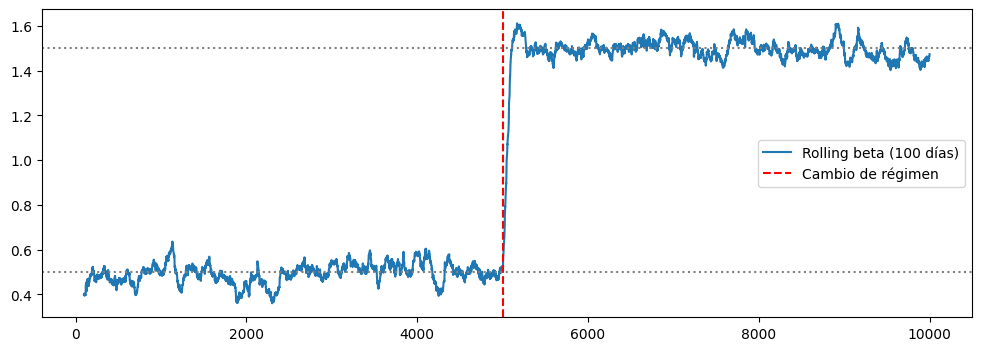

In [7]:
import numpy as np 
import  statsmodels.api as sm 
import matplotlib.pyplot as plt
# semilla 
rng = np.random.default_rng(seed=42) 
# mercado
mercado = rng.normal(scale= 0.01, size = 10_000, loc = 0 )
shocks = rng.normal(loc = 0, scale= 0.004, size = 10_000)
asset = []
asset[:5_000] = 0.5 * mercado[:5_000] + shocks[:5_000]
asset[5_000:] = 1.5 * mercado[5_000:] + shocks[5_000:]
# estiamos OSL para los 10,000 dias 
x = sm.add_constant(mercado)
# modelo 
modelo = sm.OLS(asset, x).fit()
alpha_hat = modelo.params[0]
beta_hat = modelo.params[1]
print("Full-sample beta:", beta_hat)
df = pd.DataFrame({
    "asset": asset,
    "mercado": mercado
})

ventana = 100

df["rolling_beta"] = (
    df["asset"].rolling(ventana).cov(df["mercado"])
    / df["mercado"].rolling(ventana).var()
)
beta_regimen_1 = df.loc[:4_999, "rolling_beta"].mean()
beta_regimen_2 = df.loc[5_000:, "rolling_beta"].mean()

print("Mean beta first regime:", beta_regimen_1)
print("Mean beta second regime:", beta_regimen_2)

plt.figure(figsize=(12, 4))
plt.plot(df["rolling_beta"], label="Rolling beta (100 días)")
plt.axvline(5_000, color="red", linestyle="--", label="Cambio de régimen")
plt.axhline(0.5, color="gray", linestyle=":")
plt.axhline(1.5, color="gray", linestyle=":")
plt.legend()
plt.show()

#### <b> Quant Desk + Risk | El peligro de tratar $ X $ como dato estático. </b>

 Ayer calculaste:

$$ b_t=X_t^\top w_t. $$

Ahora tienes un portfolio de dos activos:

$$ w= \begin{pmatrix} 0.6\\ 0.4 \end{pmatrix}. $$

Tu base de datos conserva:

$$ \hat\beta_{\text{old}}= \begin{pmatrix} 0.7\\ 0.8 \end{pmatrix}, $$

pero después de un cambio de régimen las exposiciones estimadas recientemente son:

$$ \hat\beta_{\text{new}}= \begin{pmatrix} 1.3\\ 1.4 \end{pmatrix}. $$

Calcula la exposición de mercado que cree tener el Risk Engine con ambas:

$$ b_{\text{old}}=\hat\beta_{\text{old}}^\top w, \qquad b_{\text{new}}=\hat\beta_{\text{new}}^\top w. $$

Si el límite es

$$ |b_{\text{market}}|\le1, $$

determina qué decisión produciría cada estimación.

Después diseña un registro mínimo para cada exposición:

- factor
- estimate
- estimation_window
- as_of_time
- n_observations
- standard_error

Tu pregunta final es la más importante de hoy:

¿por qué guardar solamente market_beta = 0.72 es insuficiente para que un Risk Engine serio tome una decisión?

- <b>R: </b>`asset_id` no aparece en la lista mínima del enunciado, pero en un Risk Engine real es indispensable: si no sabes a qué activo pertenece cada beta, no puedes calcular: $ b_{\text{market}}=\hat\beta^\top w $
- <b>R: </b> `market_beta = 0.72` es insuficiente porque no dice para qué factor o activo aplica, cuándo se estimó, con qué ventana, cuántas observaciones lo respaldan ni cuánta incertidumbre tiene. El Risk Engine no puede evaluar si sigue vigente ni si es confiable.

In [9]:
import numpy as np 
# matriz de activos 
w = np.array([0.6, 0.4])

# exposiciones viejas
beta_old =  np.array([0.7,0.8])

# hay  un cambio de régimen las exposiciones estimadas recientemente son:
beta_new =  np.array([1.3,1.4])

# Calcula la exposición de mercado que cree tener el Risk Engine con ambas:
# Si el límite es #  |b_{market}| <= 1, $$
# Una fila por estimación/régimen; una columna por activo
betas = np.vstack([beta_old, beta_new])

# b_old y b_new
exposiciones = betas @ w
print(exposiciones)
nombres = ["beta antigua", "beta reciente"]
limite = 1.0

for nombre, exposicion in zip(nombres, exposiciones):
    viola = abs(exposicion) > limite
    decision = "RECHAZAR / reducir riesgo" if viola else "PERMITIR"

    print(
        f"{nombre}: exposición = {exposicion:.2f} | "
        f"límite = {limite:.2f} | viola = {viola} | {decision}"
    )
import numpy as np
import pandas as pd

registro_exposiciones = pd.DataFrame([
    {
        "asset_id": "asset_1",
        "factor": "Market",
        "estimate": 0.7,
        "estimation_window": "rolling_100d",
        "as_of_time": "2026-09-08",
        "n_observations": 100,
        "standard_error": np.nan
    },
    {
        "asset_id": "asset_2",
        "factor": "Market",
        "estimate": 0.8,
        "estimation_window": "rolling_100d",
        "as_of_time": "2026-09-08",
        "n_observations": 100,
        "standard_error": np.nan
    },
    {
        "asset_id": "asset_1",
        "factor": "Market",
        "estimate": 1.3,
        "estimation_window": "rolling_100d",
        "as_of_time": "2026-09-09",
        "n_observations": 100,
        "standard_error": np.nan
    },
    {
        "asset_id": "asset_2",
        "factor": "Market",
        "estimate": 1.4,
        "estimation_window": "rolling_100d",
        "as_of_time": "2026-09-09",
        "n_observations": 100,
        "standard_error": np.nan
    }
])

registro_exposiciones

[0.74 1.34]
beta antigua: exposición = 0.74 | límite = 1.00 | viola = False | PERMITIR
beta reciente: exposición = 1.34 | límite = 1.00 | viola = True | RECHAZAR / reducir riesgo


,asset_id,factor,estimate,estimation_window,as_of_time,n_observations,standard_error
0,asset_1,Market,0.7,rolling_100d,2026-09-08,100,NaN
1,asset_2,Market,0.8,rolling_100d,2026-09-08,100,NaN
2,asset_1,Market,1.3,rolling_100d,2026-09-09,100,NaN
3,asset_2,Market,1.4,rolling_100d,2026-09-09,100,NaN


# <b> Jueves </b>

<b> Estadística | La misma señal, diferente turnover. </b>  

- Simula 2_000 retornos futuros con una señal ligeramente predictiva:

>`signal = np.random.normal(0, 1, 2000)`
>
>`noise  = np.random.normal(0, 0.001, 2000)`
>
>`future_return = 0.00015 * signal + noise`

Construye dos estrategias:

>`position_A = np.sign(signal)`
>
>`position_B = np.where(`
>
>    `signal > 1, 1,`
>
>    `np.where(signal < -1, -1, 0))`
> 

Para cada una calcula:

$$ grossPnL_t=position_t\,r_{t+1} $$

y turnover:

$$ TO_t=|position_t-position_{t-1}|. $$

Supón:

$$ cost_t=2\text{ bps}\times TO_t. $$

Obtén únicamente:
| Strategy | Gross Sharpe | Turnover | Total cost | Net Sharpe |
| -------- | -----------: | -------: | ---------: | ---------: |


No optimices el threshold.

La pregunta es más importante que cuál gane: 

- ¿cómo puede una estrategia utilizar una señal menos frecuentemente y terminar capturando más valor económico de ella?

Relaciona tu respuesta con:

$ predictive \   signal \neq  = trading \  rule $

In [11]:
import numpy as np 
import scipy.stats as stats 
# semilla
rng = np.random.default_rng(seed=42)
# simular señal  
signal = rng.normal(0, 1, 2000)
noise  = rng.normal(0, 0.001, 2000)
# retornos
future_return = 0.00015 * signal + noise
# dos estrategias 
position_A = np.sign(signal)
position_B = np.where(signal > 1, 1,np.where(signal < -1, -1, 0))

def pnl_turnover(estrategia, retornos):
    posicion = np.asarray(estrategia, dtype=float)
    retornos_futuros = np.asarray(retornos, dtype=float)

    if posicion.shape != retornos_futuros.shape:
        raise ValueError("Posición y retornos deben tener la misma longitud.")
    gross_pnl = posicion * retornos_futuros
    # turnover 
    turnover  = np.abs(np.diff(posicion, prepend=posicion[0]))
    #  costos 
    cost = 0.0002 * turnover
    net_pnl = gross_pnl - cost

    return {'gross_pnl' : gross_pnl, 
            'turn_over': turnover, 
             'costos' : cost, 
              'net_pnl' : net_pnl }
estrategia_a = pnl_turnover(position_A, future_return)
estrategia_b = pnl_turnover(position_B, future_return)
def sharpe_anualizado(pnl):
    return pnl.mean() / pnl.std(ddof=1) * np.sqrt(252)

print("Gross Sharpe A:", sharpe_anualizado(estrategia_a["gross_pnl"]))
print("Turnover A:", estrategia_a["turn_over"].mean())
print("Total cost A:", estrategia_a["costos"].sum())
print("Net Sharpe A:", sharpe_anualizado(estrategia_a["net_pnl"]))
print('\n')

print("Gross Sharpe A:", sharpe_anualizado(estrategia_b["gross_pnl"]))
print("Turnover A:", estrategia_b["turn_over"].mean())
print("Total cost A:", estrategia_b["costos"].sum())
print("Net Sharpe A:", sharpe_anualizado(estrategia_b["net_pnl"]))

Gross Sharpe A: 1.6723843603148079
Turnover A: 0.968
Total cost A: 0.3872000000000001
Net Sharpe A: -1.360151065943142


Gross Sharpe A: 2.1709185928061245
Turnover A: 0.5215
Total cost A: 0.2086
Net Sharpe A: -0.656632213968495


In [2]:
position_A

array([ 1., -1.,  1., ..., -1., -1.,  1.], shape=(2000,))

In [3]:
position_B

array([ 0, -1,  0, ...,  0,  0,  1], shape=(2000,))